<a href="https://colab.research.google.com/github/emy014gc/Examen_Medio_Curso/blob/main/ExMC_2101427.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Examen de Medio Curso
#Inteligencia Artificial y Redes Neuronales

---
Emilio Garza Chávez - 2101427


---
Grupo: 007 - Salon: 12206 - Hora: N5 - Fecha: 13/03/2026


Importamos lasa librerias para adquirir los datos

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Aqui cargamos el repositorio de GITHUB con el link del Forms

In [37]:
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/diamonds.csv"

df = pd.read_csv(url)

Mostramos las ultimas 5 filas de datos

In [38]:
df.tail()

,carat,cut,color,clarity,depth,table,price,x,y,z
53935,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53936,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53937,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53938,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74
53939,0.75,Ideal,D,SI2,62.2,55.0,2757,5.83,5.87,3.64


Esta tabla nos da los valores estadisticos como el promedio, desviacion, valores minimos y maximos

In [39]:
df.describe()

,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


Limpiamos los valores que dan 0 en los ejes x,y,z

In [40]:
filas_invalidas = df[(df['x'] == 0) | (df['y'] == 0) | (df['z'] == 0)]

print("Filas con dimensiones inválidas:")
print(filas_invalidas)

Filas con dimensiones inválidas:
       carat        cut color clarity  depth  table  price     x     y    z
2207    1.00    Premium     G     SI2   59.1   59.0   3142  6.55  6.48  0.0
2314    1.01    Premium     H      I1   58.1   59.0   3167  6.66  6.60  0.0
4791    1.10    Premium     G     SI2   63.0   59.0   3696  6.50  6.47  0.0
5471    1.01    Premium     F     SI2   59.2   58.0   3837  6.50  6.47  0.0
10167   1.50       Good     G      I1   64.0   61.0   4731  7.15  7.04  0.0
11182   1.07      Ideal     F     SI2   61.6   56.0   4954  0.00  6.62  0.0
11963   1.00  Very Good     H     VS2   63.3   53.0   5139  0.00  0.00  0.0
13601   1.15      Ideal     G     VS2   59.2   56.0   5564  6.88  6.83  0.0
15951   1.14       Fair     G     VS1   57.5   67.0   6381  0.00  0.00  0.0
24394   2.18    Premium     H     SI2   59.4   61.0  12631  8.49  8.45  0.0
24520   1.56      Ideal     G     VS2   62.2   54.0  12800  0.00  0.00  0.0
26123   2.25    Premium     I     SI1   61.3   58.0  15

Limpiamos las filas con los valores que no necesitamos

In [41]:
df_limpio = df[(df['x'] > 0) & (df['y'] > 0) & (df['z'] > 0)]

print("Cantidad de filas originales:", len(df))
print("Cantidad de filas después de limpiar:", len(df_limpio))

Cantidad de filas originales: 53940
Cantidad de filas después de limpiar: 53920


Calculamos volumenes aproximados para los materiales

In [42]:
df_limpio['volumen_aprox'] = df_limpio['x'] * df_limpio['y'] * df_limpio['z']

df_limpio.head()

/tmp/ipykernel_1020/3428837944.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_limpio['volumen_aprox'] = df_limpio['x'] * df_limpio['y'] * df_limpio['z']


,carat,cut,color,clarity,depth,table,price,x,y,z,volumen_aprox
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43,38.202030
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31,34.505856
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31,38.076885
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63,46.724580
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75,51.917250


Esta grafica es para observar la distribucion de los precios del diamante y los valores atipicos

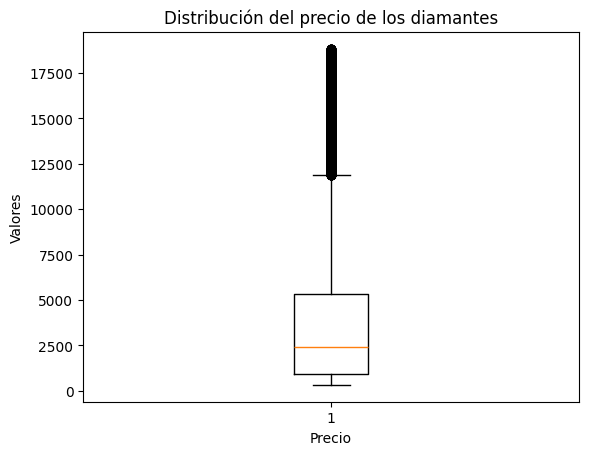

In [43]:
plt.boxplot(df_limpio['price'])

plt.title("Distribución del precio de los diamantes")
plt.xlabel("Precio")
plt.ylabel("Valores")

plt.show()

Esta grafica es para observar la distribucion de los precios del diamante y los valores atipicos

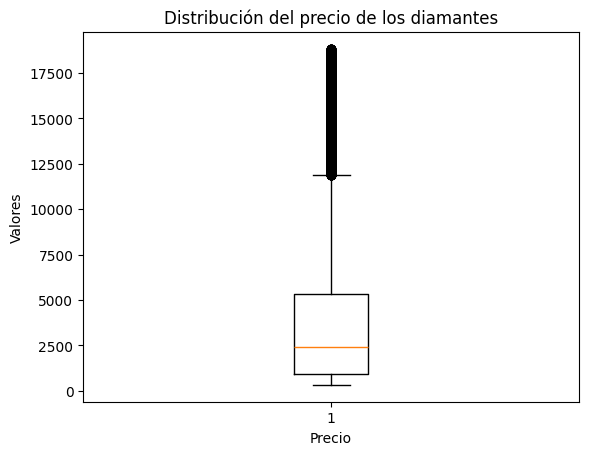

In [44]:
plt.boxplot(df_limpio['price'])

plt.title("Distribución del precio de los diamantes")
plt.xlabel("Precio")
plt.ylabel("Valores")

plt.show()

Esta otra grafica es para observar el volumen del diamante contra su tamaño

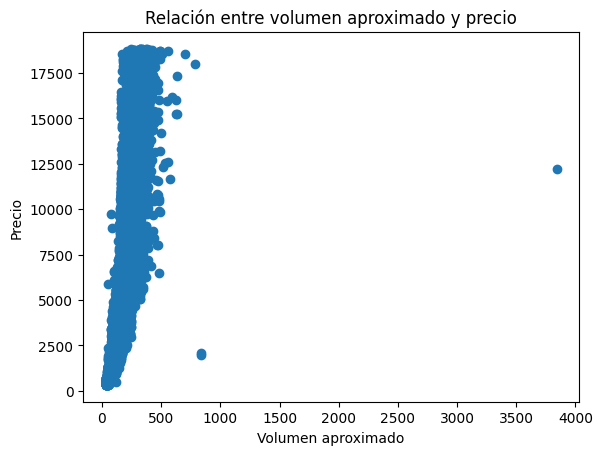

In [45]:
plt.scatter(df_limpio['volumen_aprox'], df_limpio['price'])

plt.title("Relación entre volumen aproximado y precio")
plt.xlabel("Volumen aproximado")
plt.ylabel("Precio")

plt.show()

La tercera grafica es para observar la cantidad de diamantes por cada tipo de corte

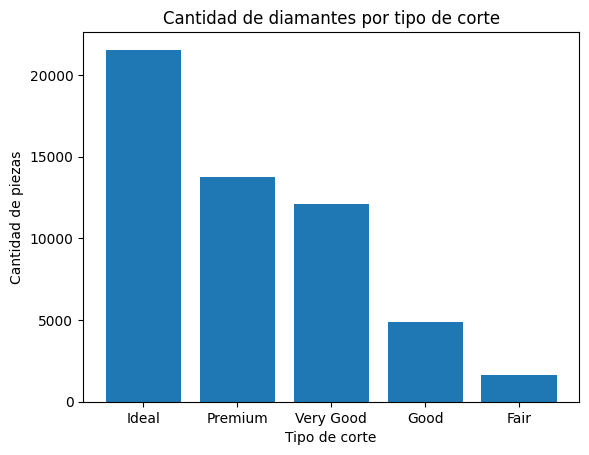

In [46]:
conteo_cortes = df_limpio['cut'].value_counts()

plt.bar(conteo_cortes.index, conteo_cortes.values)

plt.title("Cantidad de diamantes por tipo de corte")
plt.xlabel("Tipo de corte")
plt.ylabel("Cantidad de piezas")

plt.show()

Solo para mostrar que quedo limpio el Dataset

In [47]:
df_limpio.info()

<class 'pandas.core.frame.DataFrame'>
Index: 53920 entries, 0 to 53939
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   carat          53920 non-null  float64
 1   cut            53920 non-null  object 
 2   color          53920 non-null  object 
 3   clarity        53920 non-null  object 
 4   depth          53920 non-null  float64
 5   table          53920 non-null  float64
 6   price          53920 non-null  int64  
 7   x              53920 non-null  float64
 8   y              53920 non-null  float64
 9   z              53920 non-null  float64
 10  volumen_aprox  53920 non-null  float64
dtypes: float64(7), int64(1), object(3)
memory usage: 4.9+ MB
